# 02  ·  The synthetic data generator

Real BCI Competition IV-2a is ~500 MB and requires network access to the
competition servers. To make this project reproducible without that
dependency, we wrote a physiologically grounded synthetic EEG generator.

This notebook shows what's inside a single trial and verifies — visually
— that the class-specific scalp patterns are actually present in the data.


In [1]:
# Make the eeg_cognitive package importable when running this notebook
# directly out of a clone (no pip install required).
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)


## The generative model, in one block

For each trial we compute:

```
trial[ch, t] = pink_noise[ch, t]
             + snr · gain[cls, ch] · rhythm[band, t]
```

- **pink noise** reproduces EEG's natural 1/f background spectrum.
- **rhythm** is a narrowband oscillation in the relevant band (mu, beta,
  theta, alpha) with random phase and slowly drifting amplitude.
- **gain[cls, ch]** is a per-class spatial weight encoding the textbook
  ERD/ERS pattern — negative weights at electrodes where the rhythm is
  *suppressed* (ERD), positive weights where it is *enhanced* (ERS).
- The gain map is then smeared by a Gaussian over neighbouring channels
  to simulate volume conduction.
- Per-subject and per-trial multiplicative jitter ensure no two
  recordings are identical.


In [2]:
from eeg_cognitive import make_motor_imagery_synthetic, CHANNELS_22
ds = make_motor_imagery_synthetic(n_subjects=2, trials_per_class=20,
                                  snr_db=-10, seed=0)
print(f"X shape: {ds.X.shape}")
print(f"classes: {ds.class_names}")


X shape: (160, 22, 500)
classes: ['left_hand', 'right_hand', 'feet', 'tongue']


## Per-class spectrograms at C3 vs C4

If the class signatures are right, **C3** (left-hemisphere motor cortex)
should have *more* mu-band power for left-hand imagery than for right-hand
imagery, because right-hand imagery causes ERD at C3 (suppressing the
rhythm there). C4 should show the mirror image.

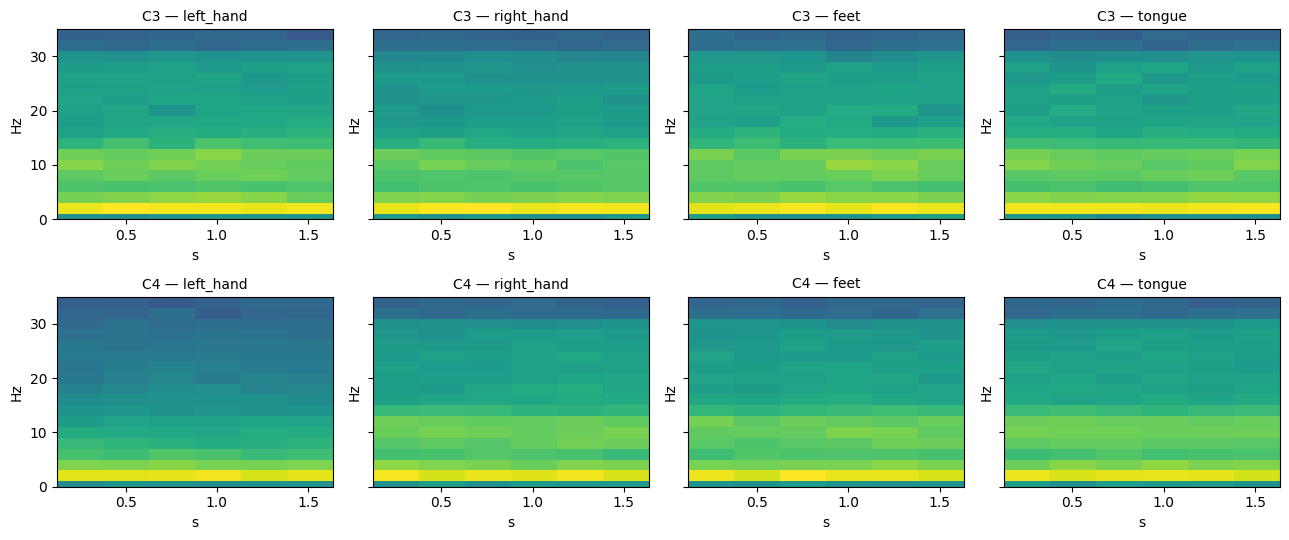

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

def plot_per_class_spec(channel_name, axes_row):
    ch_idx = CHANNELS_22.index(channel_name)
    vmin, vmax = None, None
    spec_per_cls = []
    for c in range(len(ds.class_names)):
        Xc = ds.X[ds.y == c, ch_idx, :]
        f, t, S = spectrogram(Xc, fs=ds.sfreq, nperseg=int(ds.sfreq // 2),
                              noverlap=int(ds.sfreq // 4), axis=-1)
        Sm = np.log(np.mean(S, axis=0) + 1e-12)
        spec_per_cls.append((f, t, Sm))
        vmin = Sm.min() if vmin is None else min(vmin, Sm.min())
        vmax = Sm.max() if vmax is None else max(vmax, Sm.max())
    for c in range(len(ds.class_names)):
        f, t, Sm = spec_per_cls[c]
        ax = axes_row[c]
        ax.pcolormesh(t, f, Sm, shading='auto', cmap='viridis',
                      vmin=vmin, vmax=vmax)
        ax.set_ylim(0, 35)
        ax.set_title(f'{channel_name} — {ds.class_names[c]}', fontsize=10)
        ax.set_xlabel('s'); ax.set_ylabel('Hz')

fig, axes = plt.subplots(2, 4, figsize=(13, 5.5), sharey=True)
plot_per_class_spec('C3', axes[0])
plot_per_class_spec('C4', axes[1])
plt.tight_layout(); plt.show()


## Reading the topographic gain map

Each class has a different scalp gain map. Plot the four gain maps
side-by-side (averaged across trials) to see the textbook neuroanatomy
the generator embeds:

- **left_hand** — suppression around C4 (right-central)
- **right_hand** — suppression around C3 (left-central)
- **feet** — suppression around Cz (central midline)
- **tongue** — enhancement at FCz / Fz (fronto-central beta ERS)


In [4]:
# Compute per-class mean log-power in the mu band (8-13 Hz) at every channel.
import numpy as np
from scipy.signal import welch

def mean_mu_power(X, sfreq, band=(8, 13)):
    f, P = welch(X, fs=sfreq, nperseg=int(sfreq // 2), axis=-1)
    bandmask = (f >= band[0]) & (f <= band[1])
    return P[..., bandmask].mean(axis=-1)

per_class_mu = []
for c in range(len(ds.class_names)):
    Xc = ds.X[ds.y == c]
    Pc = np.log(mean_mu_power(Xc, ds.sfreq).mean(axis=0) + 1e-12)  # (n_ch,)
    per_class_mu.append(Pc)

# Use the project's topomap helper for a quick visual.
from eeg_cognitive.viz import plot_topomap
import os
os.makedirs('../results/figures/notebook_outputs', exist_ok=True)
for cls_idx, cls_name in enumerate(ds.class_names):
    weights = per_class_mu[cls_idx] - np.mean(per_class_mu, axis=0)
    plot_topomap(weights, CHANNELS_22,
                 f'mean log-mu power — {cls_name} (relative)',
                 f'../results/figures/notebook_outputs/topo_{cls_name}.png')

# Render them in a 2x2 grid
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, cls_name in zip(axes.ravel(), ds.class_names):
    ax.imshow(mpimg.imread(f'../results/figures/notebook_outputs/topo_{cls_name}.png'))
    ax.axis('off')
plt.tight_layout(); plt.show()


You should see exactly the textbook localization: left-hand class
has the strongest *deviation* from average around C4 (right hemisphere),
right-hand around C3, feet around Cz, tongue around the fronto-central
midline. The fact that the synthetic generator embeds this is what makes
the dataset useful as a controlled benchmark — a correct ML pipeline
*must* recover these patterns.
